In [11]:
%pip install pylance

   ---------------------------------------- 0.0/82.8 MB ? eta -:--:--
   ---------------------------------------- 0.5/82.8 MB 4.8 MB/s eta 0:00:18
   - -------------------------------------- 2.1/82.8 MB 6.4 MB/s eta 0:00:13
   - -------------------------------------- 2.9/82.8 MB 6.0 MB/s eta 0:00:14
   - -------------------------------------- 3.1/82.8 MB 4.9 MB/s eta 0:00:17
   - -------------------------------------- 3.7/82.8 MB 4.0 MB/s eta 0:00:20
   - -------------------------------------- 3.9/82.8 MB 3.6 MB/s eta 0:00:22
   -- ------------------------------------- 4.5/82.8 MB 3.3 MB/s eta 0:00:25
   -- ------------------------------------- 4.7/82.8 MB 3.1 MB/s eta 0:00:25
   -- ------------------------------------- 5.2/82.8 MB 2.9 MB/s eta 0:00:27
   -- ------------------------------------- 5.2/82.8 MB 2.9 MB/s eta 0:00:27
   -- ------------------------------------- 5.5/82.8 MB 2.7 MB/s eta 0:00:30
   -- ------------------------------------- 5.8/82.8 MB 2.4 MB/s eta 0:00:32
   -- 


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
from datasets import load_dataset
ds = load_dataset("lance-format/stanford-cars-lance",split="train",cache_dir="./Datasets")
print(ds)

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Dataset({
    features: ['id', 'image', 'label', 'blip_caption', 'image_emb'],
    num_rows: 8144
})


In [3]:
import pyarrow as pa
from pathlib import Path

root = Path(
    "./Datasets/lance-format___stanford-cars-lance/"
    "default/0.0.0/359eba30c4b40a3b892e457b855690d2e29a0576"
)

for file in root.glob("*.arrow"):
    print(f"\nTesting: {file.name}")
    print(f"Size: {file.stat().st_size / 1024**2:.2f} MB")

    try:
        with pa.memory_map(str(file), "r") as f:
            reader = pa.ipc.open_stream(f)
            table = reader.read_all()

        print("Valid Arrow stream")
        print("Rows:", table.num_rows)
        print("Columns:", table.column_names)

    except Exception as e:
        print("FAILED:", repr(e))


Testing: stanford-cars-lance-train-00000-of-00002.arrow
Size: 488.06 MB
Valid Arrow stream
Rows: 4608
Columns: ['id', 'image', 'label', 'blip_caption', 'image_emb']

Testing: stanford-cars-lance-train-00001-of-00002.arrow
Size: 364.21 MB
Valid Arrow stream
Rows: 3536
Columns: ['id', 'image', 'label', 'blip_caption', 'image_emb']


In [ ]:
from datasets import load_dataset

ds = load_dataset("lance-format/stanford-cars-lance", split="train", cache_dir="./Datasets")
split = ds.train_test_split(test_size=0.10, seed=42)

train_ds = split["train"]
val_ds = split["test"]

print("Train:", len(train_ds))
print("Validation:", len(val_ds))

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/8144 [00:00<?, ? examples/s]

Train: 7329
Validation: 815


In [6]:
sample = ds[897]

print("ID:", sample["id"])
print("Label:", sample["label"])
print("Caption:", sample["blip_caption"])
print("Image:", sample["image"])

ID: 897
Label: 5
Caption: a car driving on a race track
Image: <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=600x399 at 0x29493F779D0>


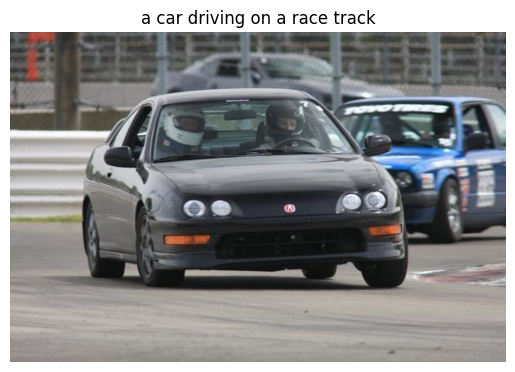

In [7]:
import matplotlib.pyplot as plt

plt.imshow(sample["image"])
plt.axis("off")
plt.title(sample["blip_caption"])
plt.show()


In [7]:
from datasets import load_dataset

ds = load_dataset("lance-format/stanford-cars-lance", split="train", cache_dir="./Datasets")

split = ds.train_test_split(test_size=0.10, seed=42)

train_ds = split["train"]
val_ds = split["test"]

print("Train:", len(train_ds))
print("Validation:", len(val_ds))

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Train: 7329
Validation: 815
